In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using CairoMakie, LaTeXStrings, MakiePublication
using JLD2, DataFrames
using StatsBase, Distributions

In [3]:
include("./DataTools.jl")
include("./MacroPatterns.jl")
include("./GOF.jl")
using .DataTools
using .MacroPatterns
using .GOF

In [4]:
# Set theme for plots
__theme = MakiePublication.theme_acs(; ishollowmarkers=[true,true])
set_theme!(__theme)

In [46]:
# Root that contains domains
root = "./Data/arx_sources"

# domain -> topic -> samples (each sample = Vector{String} lines)
domains = Dict{String, Dict{String, Vector{Vector{String}}}}()

for domain_dir in filter(isdir, readdir(root; join=true))
    domain = splitpath(domain_dir)[end]
    topic_map = Dict{String, Vector{Vector{String}}}()

    for topic_dir in filter(isdir, readdir(domain_dir; join=true))
        topic = splitpath(topic_dir)[end]
        texts_dir = joinpath(topic_dir, "texts")
        if !isdir(texts_dir); continue; end

        txt_files = filter(f -> endswith(f, ".txt"), readdir(texts_dir; join=true))
        if isempty(txt_files); continue; end

        topic_map[topic] = [readlines(f) for f in txt_files]
    end

    if !isempty(topic_map)
        domains[domain] = topic_map
    end
end


In [47]:
# Create a DataFrame with words counts for all domains and topics
df = DataFrame(
    domain = String[],
    env = String[],
    species_id = String[],
    sample_id = Int[],
    count = Int[],
    nreads = Int[]
)

for (domain, topics) in domains
    for (topic, samples) in topics
        for (i,sample) in enumerate(samples)
            # Clean each word: keep only letters/numbers
            clean_sample = [replace(w, r"^[^A-Za-z0-9]+|[^A-Za-z0-9]+$" => "") for w in sample]
            
            # Remove empty or short words
            clean_sample = filter(!isempty, clean_sample)
        
            # Count words
            cnt_map = countmap(clean_sample)
            for (k,v) in cnt_map
                push!(df, (domain, topic, k, i, v, sum(values(cnt_map))))
            end
        end
    end
end

# Remove stopwords
STOPWORDS = Set([
    "me","my","myself","we","our","ours","ourselves","you","your","yours","yourself","yourselves","he","him","his","himself",
    "she","her","hers","herself","it","its","itself","hey","them","their","theirs","themselves","what","which","who","whom",
    "this","that","these","those","am","is","are","was","were","be","been","being","have","has","had","having","do","does","did",
    "doing","an","the","and","but","if","or","because","as","until","while","of","at","by","for","with","about","against","between",
    "into","through","during","before","after","above","below","to","from","up","down","in","out","on","off","over","under","again",
    "further","then","once","here","there","when","where","why","how","all","any","both","each","few","more","most","other","some",
    "such","no","nor","not","only","own","same","so","than","too","very","can","will","just","don","should","now",
    "a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v", "w","x","y","z"
])

filter!(row -> !(row.species_id in STOPWORDS), df);

In [48]:
# Create different dfs for the different scales
agg0 = deepcopy(df)
agg0.env .= agg0.domain .* "-" .* agg0.env
select!(agg0, [:env, :species_id, :sample_id, :count, :nreads])

agg1 = select(df, [:domain, :species_id, :sample_id, :count, :nreads])
rename!(agg1, :domain => :env)

agg2 = select(df, [:species_id, :sample_id, :count, :nreads])
agg2.env .= "Math&Physics";

In [73]:
df = deepcopy(agg1)
DataTools.df_filter!(df; min_samples=5e1, min_nreads=5e3);

In [74]:
env = "nucl"
ddf = df[df.env .== env,:]
freqs = DataTools.get_frequencies(ddf, occ=0.95, rescale=false)
ν1 = freqs[:,1]
ν2 = freqs[:,3]

nbins = 20
c1, pdf1 = MacroPatterns.make_hist(log.(ν1[ν1 .> 0]), nbins=nbins)
c2, pdf2 = MacroPatterns.make_hist(log.(ν2[ν2 .> 0]), nbins=nbins);

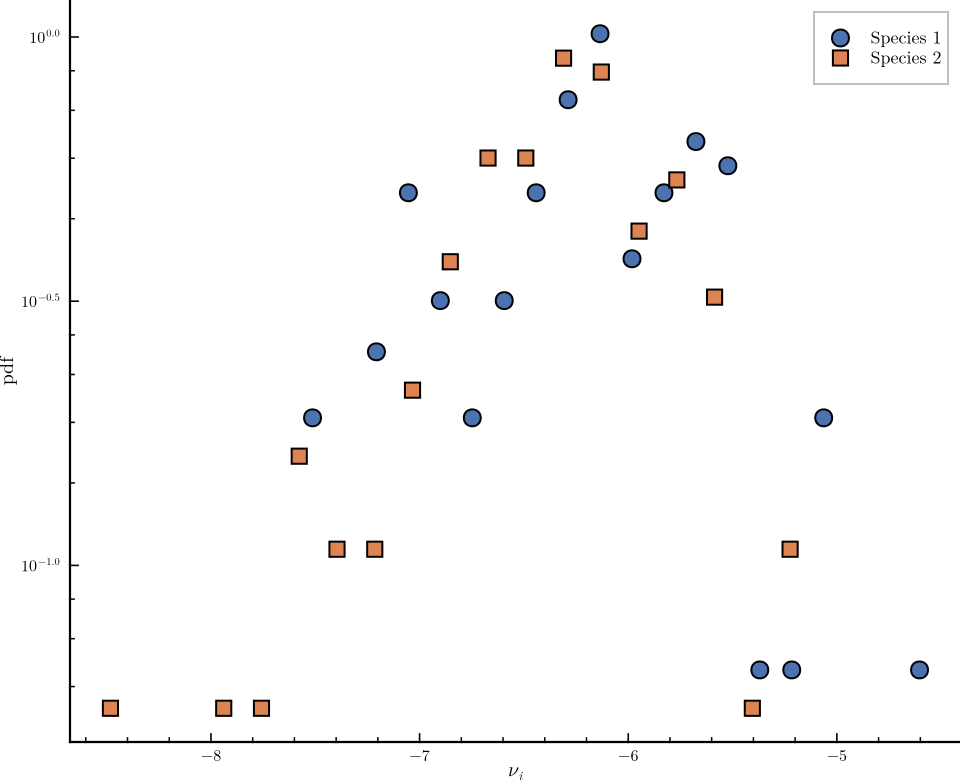

In [75]:
fig = Figure(size=(320*1.5, 260*1.5))
ax = Axis(fig[1,1], xlabel=L"$ν_i$", ylabel=L"\text{pdf}", yscale=log10)
scatter!(ax, c1, pdf1, label="Species 1", markersize=12)
scatter!(ax, c2, pdf2, label="Species 2", markersize=12)
axislegend(ax; position=:rt, framevisible=true, labelsize=9, padding=3)
fig

In [76]:
# SPECIES 1
p_n_v = []
p_g_v = []
p_p_v = []
for i in 1:size(freqs, 2)
    println("Species $i / $(size(freqs, 2))")
    data = freqs[:,i]
    data = data[data .> 0]
    pg = fit_mle(Gamma, data)
    pl = fit_mle(LogNormal, data)
    pp = fit_mle(Pareto, data)
    
    G_n(x) = cdf(LogNormal(pl.μ, pl.σ), x)
    G_g(x) = cdf(Gamma(pg.α, pg.θ), x)
    G_p(x) = cdf(Pareto(pp.α, pp.θ), x)
    
    Q_n(u) = quantile(LogNormal(pl.μ, pl.σ), u)
    Q_g(u) = quantile(Gamma(pg.α, pg.θ), u)
    Q_p(u) = quantile(Pareto(pp.α, pp.θ), u)
    
    p_n = GOF.MC_gof(data, G_n, Q_n, GOF.AD)
    p_g = GOF.MC_gof(data, G_g, Q_g, GOF.AD)
    p_p = GOF.MC_gof(data, G_p, Q_p, GOF.AD)

    push!(p_n_v, p_n)
    push!(p_g_v, p_g)
    push!(p_p_v, p_p)
end;

Species 1 / 30
Species 2 / 30
Species 3 / 30
Species 4 / 30
Species 5 / 30
Species 6 / 30
Species 7 / 30
Species 8 / 30
Species 9 / 30
Species 10 / 30
Species 11 / 30
Species 12 / 30
Species 13 / 30
Species 14 / 30
Species 15 / 30
Species 16 / 30
Species 17 / 30
Species 18 / 30
Species 19 / 30
Species 20 / 30
Species 21 / 30
Species 22 / 30
Species 23 / 30
Species 24 / 30
Species 25 / 30
Species 26 / 30
Species 27 / 30
Species 28 / 30
Species 29 / 30
Species 30 / 30


In [77]:
println("LogNormal    mean: $(mean(p_n_v))      std: $(std(p_n_v))")
println("Gamma        mean: $(mean(p_g_v))      std: $(std(p_g_v))")
println("Pareto       mean: $(mean(p_p_v))      std: $(std(p_p_v))")

LogNormal    mean: 0.5578166666666665      std: 0.21793271831609792
Gamma        mean: 0.6772133333333332      std: 0.26353423219807687
Pareto       mean: 0.0      std: 0.0
